In [2]:
pip install nltk


Defaulting to user installation because normal site-packages is not writeable
  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
    PyYAML (>=5.1.*)
            ~~~~~~^
Note: you may need to restart the kernel to use updated packages.


/home/vitoupro/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train Loss: 2.1708

✅ Epoch 0 Evaluation Summary:
   Val Loss: 1.3717
   WER     : 1.000
   CER     : 0.500
   BLEU-1  : 0.584
   BLEU-2  : 0.469
   BLEU-3  : 0.393
   BLEU-4  : 0.327
   Skipped : 0 samples
Epoch 2: Train Loss: 1.3287

✅ Epoch 1 Evaluation Summary:
   Val Loss: 1.0533
   WER     : 0.999
   CER     : 0.400
   BLEU-1  : 0.639
   BLEU-2  : 0.540
   BLEU-3  : 0.468
   BLEU-4  : 0.402
   Skipped : 0 samples
Epoch 3: Train Loss: 1.1268

✅ Epoch 2 Evaluation Summary:
   Val Loss: 0.9163
   WER     : 0.997
   CER     : 0.375
   BLEU-1  : 0.693
   BLEU-2  : 0.600
   BLEU-3  : 0.528
   BLEU-4  : 0.459
   Skipped : 0 samples
Epoch 4: Train Loss: 1.0192

✅ Epoch 3 Evaluation Summary:
   Val Loss: 0.8606
   WER     : 0.998
   CER     : 0.350
   BLEU-1  : 0.684
   BLEU-2  : 0.597
   BLEU-3  : 0.530
   BLEU-4  : 0.467
   Skipped : 0 samples
Epoch 5: Train Loss: 0.9705

✅ Epoch 4 Evaluation Summary:
   Val Loss: 0.8173
   WER     : 0.997
   CER     : 0.329
   BLEU-1  : 0.715


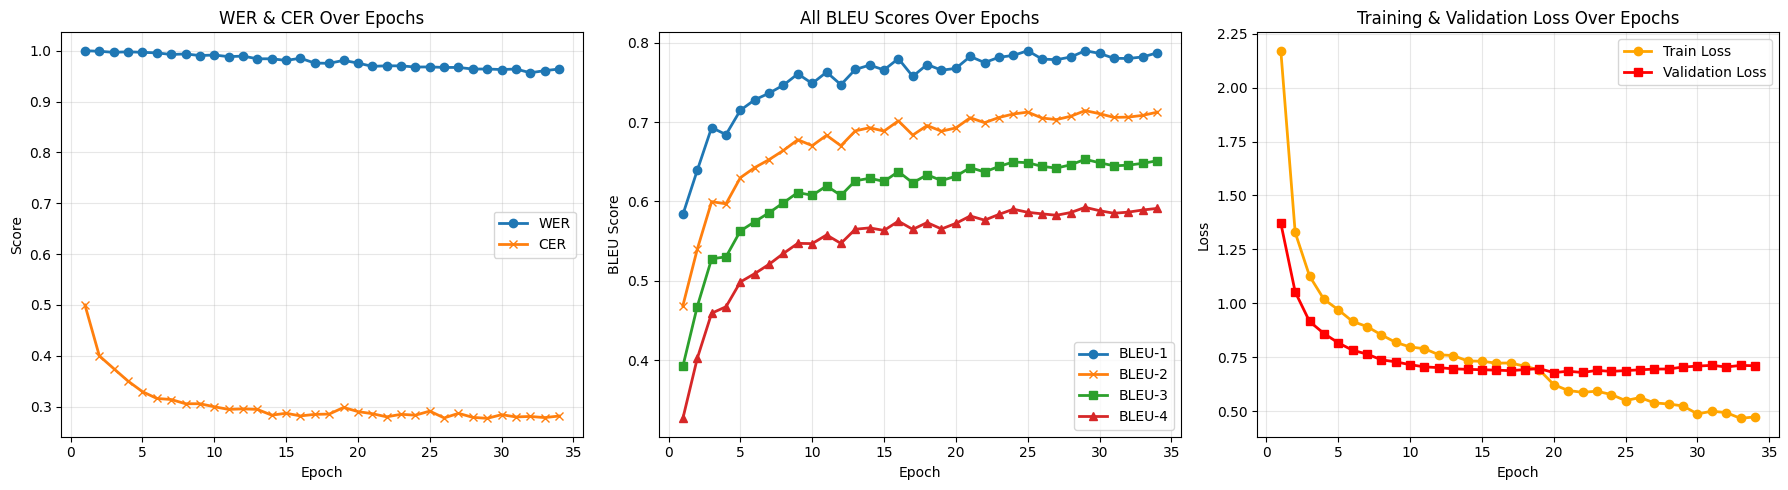


📊 Training completed after 34 epochs
📈 Best BLEU-4 score: 0.5925
💾 Models saved as 'encoder_final_defense.pth' and 'decoder_final_defense.pth'


In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from PIL import Image
import pandas as pd
import os
import re
import json
from sklearn.model_selection import train_test_split
import jiwer
import matplotlib.pyplot as plt
import timm

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Encoding and decoding functions
def encode_khmer_word(word, word2idx):
    indices = []
    for character in word:
        index = word2idx.get(character)
        if index is None:
            return None, f"Character '{character}' not found in vocabulary!"
        indices.append(index)
    return indices, None

def decode_indices(indices, idx2word):
    characters = []
    for index in indices:
        character = idx2word.get(str(index))
        if character is None:
            return None, f"Index '{index}' not found in idx2word!"
        characters.append(character)
    return ''.join(characters), None

# Attention Module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        modules = list(resnet.children())[:-2]  # Keep up to final conv layer
        self.resnet = nn.Sequential(*modules)

    def forward(self, images):
        features = self.resnet(images)  # Output: (B, 2048, 7, 7)
        features = features.permute(0, 2, 3, 1)  # (B, 7, 7, 2048)
        features = features.view(features.size(0), -1, features.size(-1))  # (B, 49, 2048)
        return features

    
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048, num_layers=1, dropout_prob=0.3):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        vocab_size = self.linear.out_features

        # Init hidden state and cell state
        h = self.init_h(encoder_out.mean(dim=1))  # (B, hidden_size)
        c = self.init_c(encoder_out.mean(dim=1))

        outputs = torch.zeros(batch_size, seq_len - 1, vocab_size).to(encoder_out.device)

        for t in range(seq_len - 1):
            embeddings = self.dropout(self.embed(captions[:, t]))  # (B, embed_size)
            context, _ = self.attention(encoder_out, h)            # (B, encoder_dim)
            lstm_input = torch.cat([embeddings, context], dim=1)   # (B, embed + encoder_dim)
            h, c = self.lstm(lstm_input, (h, c))                   # LSTMCell
            output = self.linear(self.dropout(h))                 # (B, vocab_size)
            outputs[:, t, :] = output

        return outputs

# Image Captioning Dataset
class ImageCaptionDataset(torch.utils.data.Dataset):
    def __init__(self, img_labels, img_dir, vocab, transform=None, max_length=50):
        self.img_labels = img_labels
        self.img_dir = img_dir
        self.vocab = vocab
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        caption = self.img_labels.iloc[idx, 1]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        indices, error = encode_khmer_word(caption, self.vocab)
        if error:
            print(f"Error encoding caption: {error}")
            indices = [self.vocab['<UNK>']] * self.max_length
        tokens = [self.vocab['<START>']] + indices + [self.vocab['<END>']]
        tokens += [self.vocab['<PAD>']] * (self.max_length - len(tokens))
        return image, torch.tensor(tokens[:self.max_length])

# Define transformations
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
]) 

# Load dataset
annotations_file = '/home/vitoupro/code/image_captioning/notebook/finaldata.txt'
img_dir = '/home/vitoupro/code/image_captioning/notebook/downloaded_images'
# Robust custom loader to handle inconsistent spacing
data = []
with open(annotations_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(maxsplit=1)
        if len(parts) == 2:
            img_path, caption = parts
            data.append((img_path, caption))
        else:
            print(f"Skipping malformed line: {line}")

all_images = pd.DataFrame(data, columns=['image', 'caption'])


# Split dataset
train_images, eval_images, train_captions, eval_captions = train_test_split(
    all_images['image'].tolist(), all_images['caption'].tolist(), test_size=0.2, random_state=42
)

train_dataset = ImageCaptionDataset(
    img_labels=pd.DataFrame({'image': train_images, 'caption': train_captions}),
    img_dir=img_dir,
    vocab=word2idx,
    transform=transform,
    max_length=50
)

eval_dataset = ImageCaptionDataset(
    img_labels=pd.DataFrame({'image': eval_images, 'caption': eval_captions}),
    img_dir=img_dir,
    vocab=word2idx,
    transform=transform,
    max_length=50
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=16, shuffle=False)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize models
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx), num_layers=1,dropout_prob=0.5).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<PAD>'])
params = list(decoder.parameters()) + list(encoder.parameters())
optimizer = torch.optim.Adam(params, lr=0.001)

def custom_transform(text):
    # Lowercase the text
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Return as list of words
    return text.split()

    

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import re
import jiwer

smoothing = SmoothingFunction().method4  # More stable smoothing

def calculate_wer(gt, pred, epoch, file_path='metric.txt'):
    match_pred = re.search(r"^(.*?)<END>", pred)
    content_pred = match_pred.group(1) if match_pred else ""

    match_gt = re.search(r"<START>(.*?)<END>", gt)
    content_gt = match_gt.group(1) if match_gt else ""

    with open(file_path, 'a') as file:
        file.write(f"Epoch {epoch}\n")
        file.write("===========================\n")
        file.write(f"pred: {content_pred}\n")
        file.write(f"true: {content_gt}\n")
        file.write("===========================\n")

    return jiwer.wer(content_gt or '', content_pred or '')

def calculate_cer(gt, pred):
    match_pred = re.search(r"^(.*?)<END>", pred)
    content_pred = match_pred.group(1) if match_pred else ""

    match_gt = re.search(r"<START>(.*?)<END>", gt)
    content_gt = match_gt.group(1) if match_gt else ""

    return jiwer.cer(content_gt or '', content_pred or '')

def evaluate_model(encoder, decoder, dataloader, device, epoch, criterion):
    encoder.eval()
    decoder.eval()

    total_wer, total_cer = 0, 0
    total_val_loss = 0
    num_samples = 0
    skipped = 0

    all_references = []
    all_predictions = []

    with torch.no_grad():
        for batch_idx, (images, captions) in enumerate(dataloader):
            images, captions = images.to(device), captions.to(device)
            features = encoder(images)
            inputs = captions[:, :-1]
            targets = captions[:, 1:]
            
            batch_size, seq_len = inputs.size()
            h = decoder.init_h(features.mean(dim=1))
            c = decoder.init_c(features.mean(dim=1))
            
            outputs = torch.zeros(batch_size, seq_len, len(word2idx)).to(features.device)
            
            # Manual stepping through decoder (same as training, but without scheduled sampling)
            for t in range(seq_len):
                embedded = decoder.dropout(decoder.embed(inputs[:, t]))
                context, _ = decoder.attention(features, h)
                lstm_input = torch.cat([embedded, context], dim=1)
                h, c = decoder.lstm(lstm_input, (h, c))
                out = decoder.linear(decoder.dropout(h))
                outputs[:, t] = out
            
            # Calculate validation loss
            val_loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
            total_val_loss += val_loss.item()
            
            predicted_captions = outputs.argmax(-1)

            for i in range(captions.size(0)):
                gt_ids = captions[i].tolist()
                pred_ids = predicted_captions[i].tolist()

                gt_text, gt_err = decode_indices(gt_ids, idx2word)
                pred_text, pred_err = decode_indices(pred_ids, idx2word)

                if not gt_text or not pred_text or gt_err or pred_err:
                    skipped += 1
                    continue

                # Extract only content between <START> and <END>
                ref_match = re.search(r"<START>(.*?)<END>", gt_text)
                pred_match = re.search(r"^(.*?)<END>", pred_text)
                reference = ref_match.group(1).strip() if ref_match else ""
                prediction = pred_match.group(1).strip() if pred_match else ""

                if not reference or not prediction:
                    continue

                wer = calculate_wer(gt_text, pred_text, epoch)
                cer = calculate_cer(gt_text, pred_text)
                total_wer += wer
                total_cer += cer
                num_samples += 1

                # Use character-level tokens for BLEU
                ref_chars = list(reference)
                pred_chars = list(prediction)

                if len(ref_chars) == 0 or len(pred_chars) == 0:
                    continue

                all_references.append([ref_chars])  # list of one reference
                all_predictions.append(pred_chars)

    # Corpus-level BLEU
    # Corpus-level BLEU
    bleu1 = corpus_bleu(all_references, all_predictions, weights=(1, 0, 0, 0), smoothing_function=smoothing)
    bleu2 = corpus_bleu(all_references, all_predictions, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    bleu3 = corpus_bleu(all_references, all_predictions, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothing)
    bleu4 = corpus_bleu(all_references, all_predictions, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)
 

    avg_wer = total_wer / num_samples if num_samples else 1.0
    avg_cer = total_cer / num_samples if num_samples else 1.0
    avg_val_loss = total_val_loss / len(dataloader)

    print(f"\n✅ Epoch {epoch} Evaluation Summary:")
    print(f"   Val Loss: {avg_val_loss:.4f}")
    print(f"   WER     : {avg_wer:.3f}")
    print(f"   CER     : {avg_cer:.3f}")
    print(f"   BLEU-1  : {bleu1:.3f}")
    print(f"   BLEU-2  : {bleu2:.3f}")
    print(f"   BLEU-3  : {bleu3:.3f}")
    print(f"   BLEU-4  : {bleu4:.3f}")
    print(f"   Skipped : {skipped} samples")

    return avg_wer, avg_cer, bleu1, bleu2, bleu3, bleu4, avg_val_loss



# Training Loop
num_epochs = 50
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F

# Scheduled Sampling
scheduled_sampling_start = 0.0
scheduled_sampling_end = 0.3
scheduled_sampling_increase = (scheduled_sampling_end - scheduled_sampling_start) / num_epochs

# Label Smoothing (Optional)
def label_smoothing_loss(pred, target, smoothing=0.1):
    confidence = 1.0 - smoothing
    logprobs = F.log_softmax(pred, dim=-1)
    nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
    smooth_loss = -logprobs.mean(dim=-1)
    return (confidence * nll_loss + smoothing * smooth_loss).mean()

# Scheduler based on BLEU-4 improvement
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

# Training Loop
best_bleu4 = 0.0
early_stopping_patience = 5
epochs_no_improve = 0
train_losses, val_losses, wer_scores, cer_scores = [], [], [], []
bleu1_scores, bleu2_scores, bleu3_scores, bleu4_scores = [], [], [], []

for epoch in range(num_epochs): 
    

    encoder.train()
    decoder.train()
    total_loss = 0 
    sampling_prob = min(scheduled_sampling_start + epoch * scheduled_sampling_increase, scheduled_sampling_end)

    for images, captions in train_loader:
        images, captions = images.to(device), captions.to(device)
        features = encoder(images)
        inputs = captions[:, :-1]
        targets = captions[:, 1:]

        batch_size, seq_len = inputs.size()
        h = decoder.init_h(features.mean(dim=1))
        c = decoder.init_c(features.mean(dim=1))

        outputs = torch.zeros(batch_size, seq_len, len(word2idx)).to(device)

        for t in range(seq_len):
            if t == 0 or torch.rand(1).item() >= sampling_prob:
                prev_input = inputs[:, t]
            else:
                prev_input = outputs[:, t-1].argmax(dim=-1)

            embedded = decoder.dropout(decoder.embed(prev_input))
            context, _ = decoder.attention(features, h)
            lstm_input = torch.cat([embedded, context], dim=1)
            h, c = decoder.lstm(lstm_input, (h, c))
            out = decoder.linear(decoder.dropout(h))
            outputs[:, t] = out

        outputs = outputs.reshape(-1, outputs.size(-1))
        targets = targets.reshape(-1)

        loss = criterion(outputs, targets)
        # Alternative: enable label smoothing
        # loss = label_smoothing_loss(outputs, targets, smoothing=0.1)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(params, max_norm=5.0)  # Gradient clipping
        optimizer.step()
        total_loss += loss.item()

    print(f'Epoch {epoch+1}: Train Loss: {total_loss / len(train_loader):.4f}')

    wer, cer, bleu1, bleu2, bleu3, bleu4, val_loss = evaluate_model(encoder, decoder, eval_loader, device, epoch, criterion)
    scheduler.step(bleu4)

    train_losses.append(total_loss / len(train_loader))
    val_losses.append(val_loss)
    wer_scores.append(wer)
    cer_scores.append(cer)
    bleu1_scores.append(bleu1)
    bleu2_scores.append(bleu2)
    bleu3_scores.append(bleu3)
    bleu4_scores.append(bleu4)

  

        

    if bleu4 > best_bleu4:
        best_bleu4 = bleu4
        epochs_no_improve = 0
        torch.save(encoder.state_dict(), 'encoder_final_defense.pth')
        torch.save(decoder.state_dict(), 'decoder_final_defense.pth')
    else:
        epochs_no_improve += 1
        print(f"🔁 No BLEU-4 improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= early_stopping_patience:
        print(f"⏹️ Early stopping triggered at epoch {epoch+1} (no BLEU-4 improvement in {early_stopping_patience} epochs).")
        break

# Use actual number of epochs trained (handle early stopping)
actual_epochs = len(train_losses)
epochs = list(range(1, actual_epochs + 1))

# Create three separate visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: WER and CER
axes[0].plot(epochs, wer_scores, label='WER', marker='o', linewidth=2)
axes[0].plot(epochs, cer_scores, label='CER', marker='x', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Score')
axes[0].set_title('WER & CER Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: All BLEU Scores
axes[1].plot(epochs, bleu1_scores, label='BLEU-1', marker='o', linewidth=2)
axes[1].plot(epochs, bleu2_scores, label='BLEU-2', marker='x', linewidth=2)
axes[1].plot(epochs, bleu3_scores, label='BLEU-3', marker='s', linewidth=2)
axes[1].plot(epochs, bleu4_scores, label='BLEU-4', marker='^', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BLEU Score')
axes[1].set_title('All BLEU Scores Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Train Loss and Validation Loss
axes[2].plot(epochs, train_losses, label='Train Loss', color='orange', marker='o', linewidth=2)
axes[2].plot(epochs, val_losses, label='Validation Loss', color='red', marker='s', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Training & Validation Loss Over Epochs')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_evaluation_metrics_defense.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Training completed after {actual_epochs} epochs")
print(f"📈 Best BLEU-4 score: {best_bleu4:.4f}")
print(f"💾 Models saved as 'encoder_final_defense.pth' and 'decoder_final_defense.pth'")

        

/home/vitoupro/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vitoupro/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


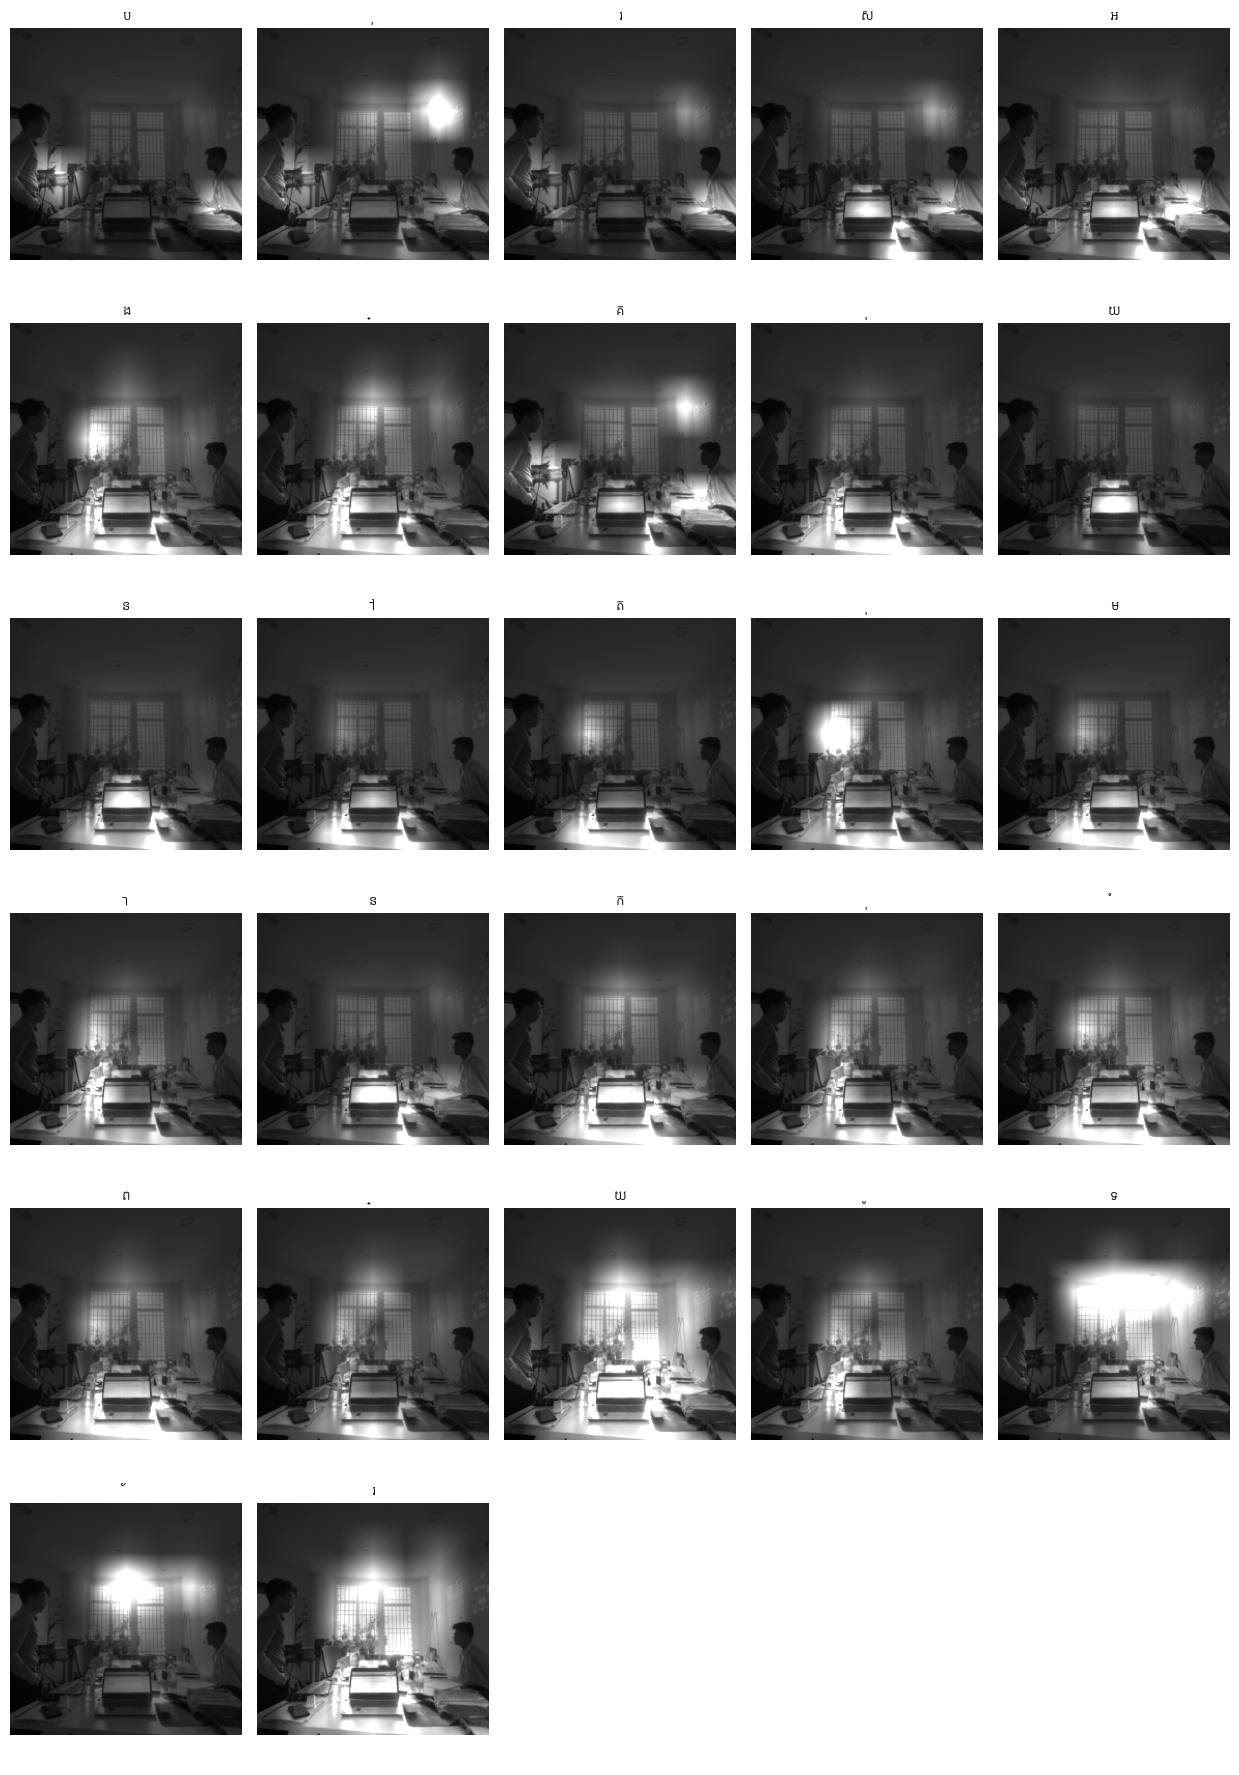

Generated Caption: បុរសអង្គុយនៅតុមានកុំព្យូទ័រ


In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])

    def forward(self, images):
        features = self.resnet(images)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

def create_soft_spotlight(img_tensor, attention_map):
    """Create a soft spotlight overlay using gray-to-white gradient"""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    
    # Resize attention map to match image dimensions
    attention_resized = cv2.resize(attention_map, (img.shape[1], img.shape[0]))
    
    # Normalize attention to 0-1 range
    attention_norm = (attention_resized - attention_resized.min()) / (attention_resized.max() - attention_resized.min() + 1e-8)
    
    # Create spotlight effect: gray background with white highlights
    # Convert to grayscale first
    img_gray = np.dot(img, [0.299, 0.587, 0.114])
    img_gray = np.stack([img_gray] * 3, axis=-1)  # Convert back to 3-channel
    
    # Create spotlight mask: 0.3 (dark gray) to 1.0 (white)
    spotlight_intensity = 0.3 + 2* attention_norm
    spotlight_mask = np.stack([spotlight_intensity] * 3, axis=-1)
    
    # Apply spotlight effect
    spotlighted_img = img_gray * spotlight_mask
    
    return np.clip(spotlighted_img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_defense.pth'))
decoder.load_state_dict(torch.load('decoder_final_defense.pth'))
encoder.eval()
decoder.eval()

# Generate caption using beam search and visualize attention with soft spotlight
def generate_caption_with_spotlight(image_path, beam_size=5):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_spotlights = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    spotlight_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c = decoder.forward_step(encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]

        # Generate attention spotlight for top candidate
        with torch.no_grad():
            _, alpha = decoder.attention(encoder_out, h)  # (k, 196)
            attention_map = alpha[0].view(7, 7).cpu().numpy()
            spotlight_img = create_soft_spotlight(img_for_display, attention_map)
            spotlight_list[0].append(spotlight_img)

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_spotlights.extend([spotlight_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        spotlight_list = [spotlight_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_spotlights = complete_spotlights[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(best_spotlights[i])
            ax.set_title(tokens[i], fontsize=300, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/data/interim/image.png'
# Run
caption = generate_caption_with_spotlight(image_path)
print("Generated Caption:", caption)
